# Mapping

In [ ]:
from pathlib import Path
import sys
import os

ROOT = Path(os.getcwd())

# if notebook is in notebooks/, go up one level
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

sys.path.append(str(ROOT))

In [4]:
import pandas as pd

In [8]:
data = pd.read_pickle(DATA/'ml_datasets_ARCHIVE/all_raw_samples.pkl')

In [7]:
features = pd.read_pickle(DATA/'ml_datasets_ARCHIVE/L2_DATASET_mapping.pkl')


target_cols =  ['EX_o2_e','EX_glc__D_e', 'EX_ac_e', 'EX_lcts_e', 'EX_glyc_e', 'EX_arg__L_e', 'EX_nh4_e', 'EX_no3_e']
target = data[target_cols]

**Transforming target**

In [9]:
import numpy as np
from sklearn.preprocessing import normalize

In [10]:
target_uptake = target.clip(upper=0).abs()

target_log = np.log1p(target_uptake)
target_norm = normalize(target_log, norm='l2', axis=1)

target_trans = pd.DataFrame(
    target_norm,
    index=target.index,
    columns=target.columns
)

target_trans['source'] = data['source'].values

## 1. Euclidean distances

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import pairwise_distances
color_map = sns.color_palette("GnBu", as_cmap=True)

In [12]:
X = features.iloc[:, :5]
Y = target_trans.drop(columns='source')

### Distance-distance plot

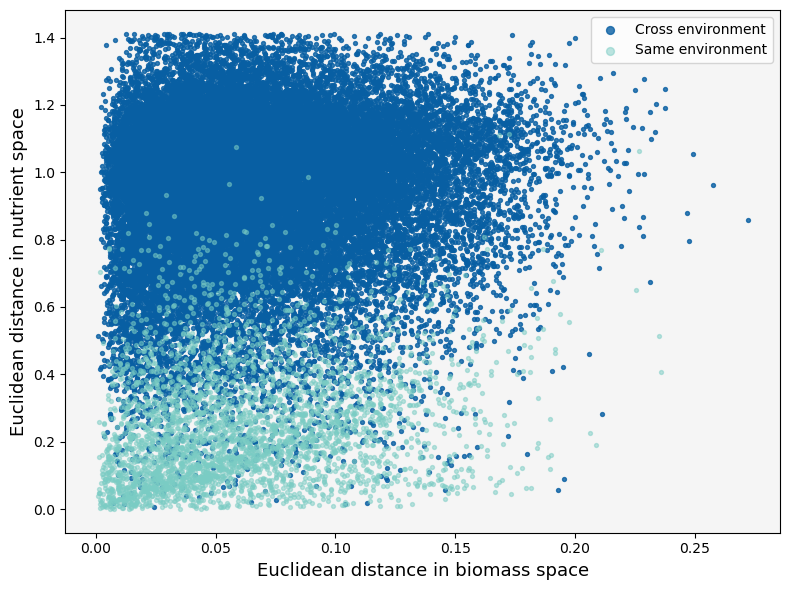

In [21]:
labels = target_trans['source'].values

DX = pairwise_distances(X, metric="euclidean")
DY = pairwise_distances(Y, metric="euclidean")


i, j = np.triu_indices_from(DX, k=1)
dx = DX[i, j]
dy = DY[i, j]
same = labels[i] == labels[j]


max_pairs = 40000
if len(dx) > max_pairs:
    idx = np.random.choice(len(dx), size=max_pairs, replace=False)
    dx = dx[idx]
    dy = dy[idx]
    same = same[idx]


fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(dx[~same], dy[~same], s=8, alpha=0.8, label="Cross environment", color=color_map(0.9))
ax.scatter(dx[same],  dy[same],  s=8, alpha=0.5, label="Same environment", color=color_map(0.5))
# ax.scatter(dx[same],  dy[same],  s=8, alpha=0.3, label="Same environment", color='red')
ax.legend(markerscale=2)
ax.set_xlabel("Euclidean distance in biomass space", fontsize=13)
ax.set_ylabel("Euclidean distance in nutrient space", fontsize=13)
# ax.set_title("Pairwise distances in biomass vs nutrient Space", fontsize=17)
ax.set_facecolor('whitesmoke')
plt.tight_layout()
plt.show()

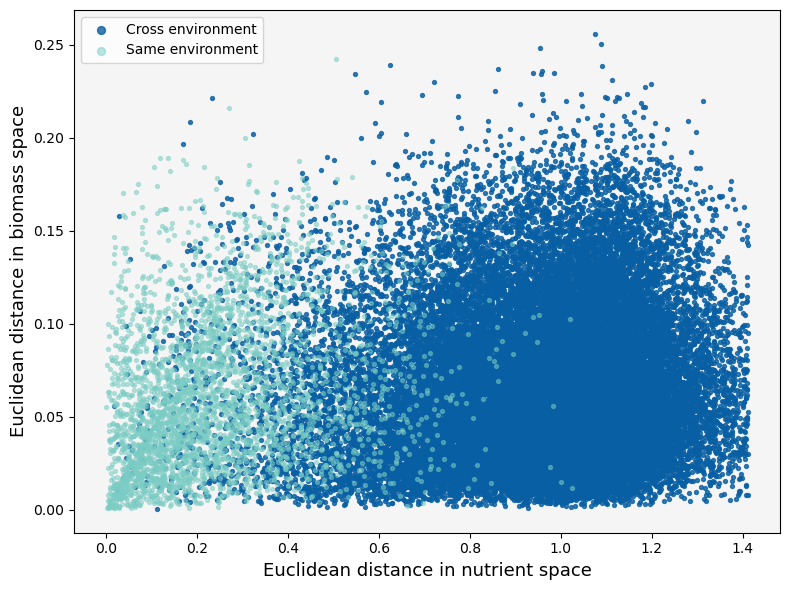

In [15]:
labels = target_trans['source'].values

DX = pairwise_distances(Y, metric="euclidean")
DY = pairwise_distances(X, metric="euclidean")


i, j = np.triu_indices_from(DX, k=1)
dx = DX[i, j]
dy = DY[i, j]
same = labels[i] == labels[j]


max_pairs = 40000
if len(dx) > max_pairs:
    idx = np.random.choice(len(dx), size=max_pairs, replace=False)
    dx = dx[idx]
    dy = dy[idx]
    same = same[idx]


fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(dx[~same], dy[~same], s=8, alpha=0.8, label="Cross environment", color=color_map(0.9))
ax.scatter(dx[same],  dy[same],  s=8, alpha=0.5, label="Same environment", color=color_map(0.5))
# ax.scatter(dx[same],  dy[same],  s=8, alpha=0.3, label="Same environment", color='red')
ax.legend(markerscale=2)
ax.set_ylabel("Euclidean distance in biomass space", fontsize=13)
ax.set_xlabel("Euclidean distance in nutrient space", fontsize=13)
# ax.set_title("Pairwise distances in biomass vs nutrient Space", fontsize=17)
ax.set_facecolor('whitesmoke')
plt.tight_layout()
plt.show()

### Heatmap

**Centroids**

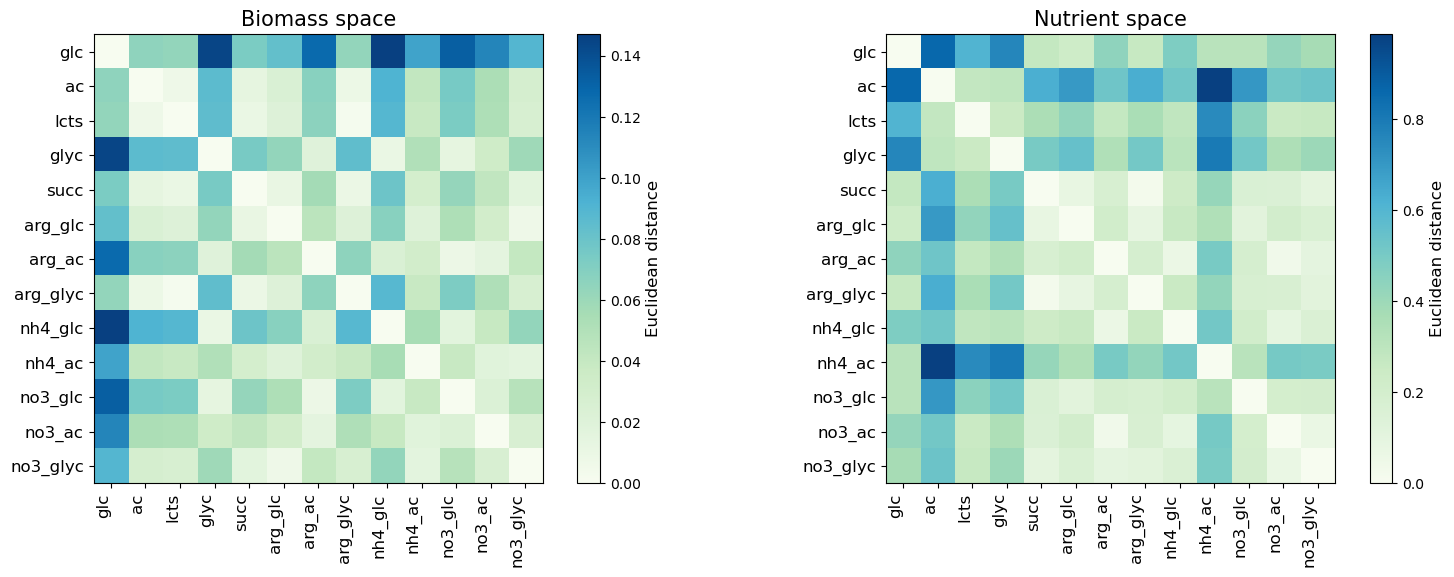

In [38]:
labels = target_trans['source'].values

unique_envs = np.unique(labels)
X_centroids = np.array([X[labels == env].mean(axis=0) for env in unique_envs])
Y_centroids = np.array([Y[labels == env].mean(axis=0) for env in unique_envs])

env_order = ['glc', 'ac', 'lcts', 'glyc', 'succ', 'arg_glc', 'arg_ac', 'arg_glyc',
             'nh4_glc', 'nh4_ac', 'no3_glc', 'no3_ac', 'no3_glyc']
order_idx = [list(unique_envs).index(env) for env in env_order]

DX_ordered = DX[np.ix_(order_idx, order_idx)]
DY_ordered = DY[np.ix_(order_idx, order_idx)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, D, title in zip(axes, [DX_ordered, DY_ordered], ["Biomass space", "Nutrient space"]):
    im = ax.imshow(D, cmap="GnBu")
    ax.set_xticks(range(len(env_order)))
    ax.set_yticks(range(len(env_order)))
    ax.set_xticklabels(env_order, rotation=90, ha="right", fontsize=12)
    ax.set_yticklabels(env_order, fontsize=12)
    ax.set_title(f"{title}", fontsize=15)
    # plt.colorbar(im, ax=ax)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Euclidean distance", fontsize=12)


# plt.suptitle('Centroid distances between environments', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [54]:
import matplotlib as mpl

biomass_cmap = mpl.colormaps["YlGnBu"]
biomass_cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "YlGnBu_trunc", biomass_cmap(np.linspace(0.0, 0.29, 256))
)

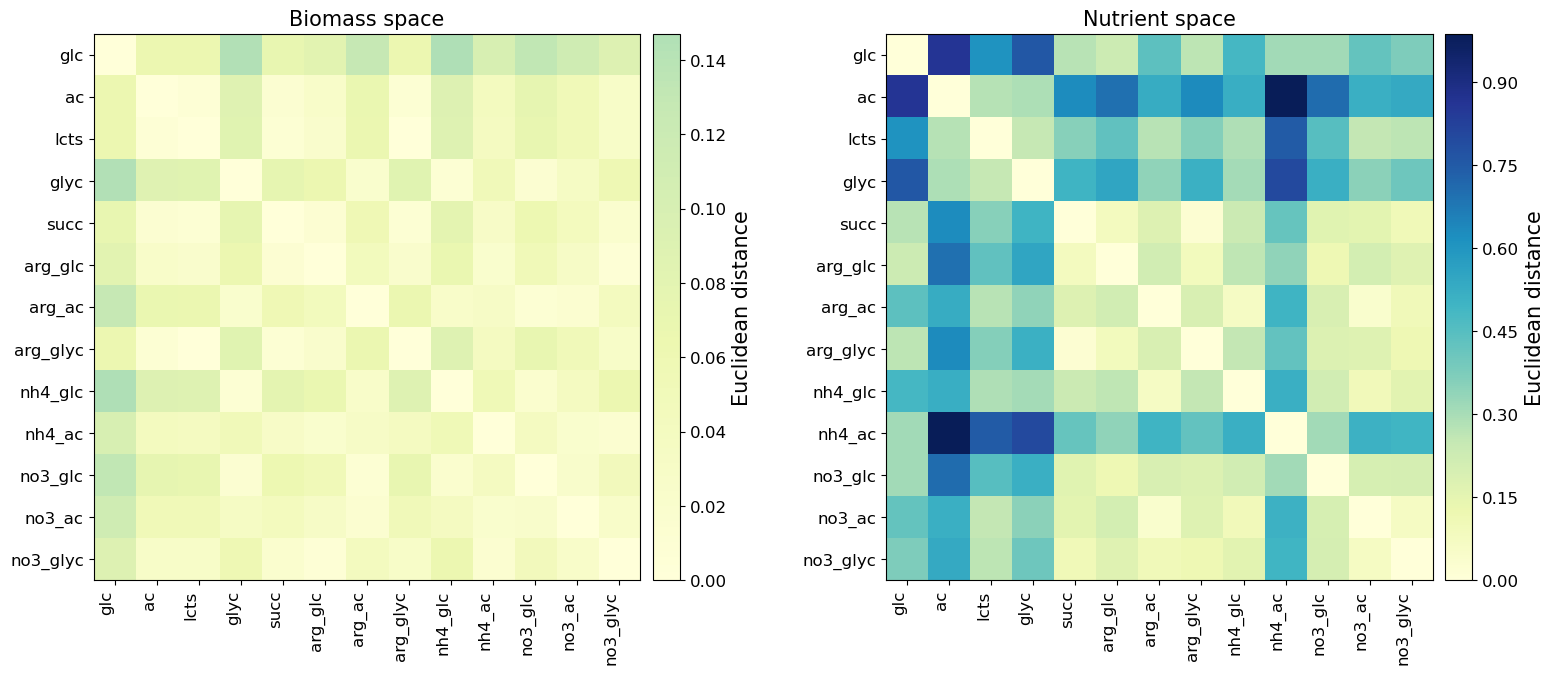

In [64]:
cmaps = [biomass_cmap, "YlGnBu"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, D, title, cmap in zip(axes, [DX_ordered, DY_ordered], ["Biomass space", "Nutrient space"], cmaps):
    im = ax.imshow(D, cmap=cmap)
    ax.set_xticks(range(len(env_order)))
    ax.set_yticks(range(len(env_order)))
    ax.set_xticklabels(env_order, rotation=90, ha="right", fontsize=12)
    ax.set_yticklabels(env_order, fontsize=12)
    ax.set_title(title, fontsize=15)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label("Euclidean distance", fontsize=15)
    cbar.ax.tick_params(labelsize=12)

cbar.set_ticks(np.arange(0, DY_ordered.max(), 0.15))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

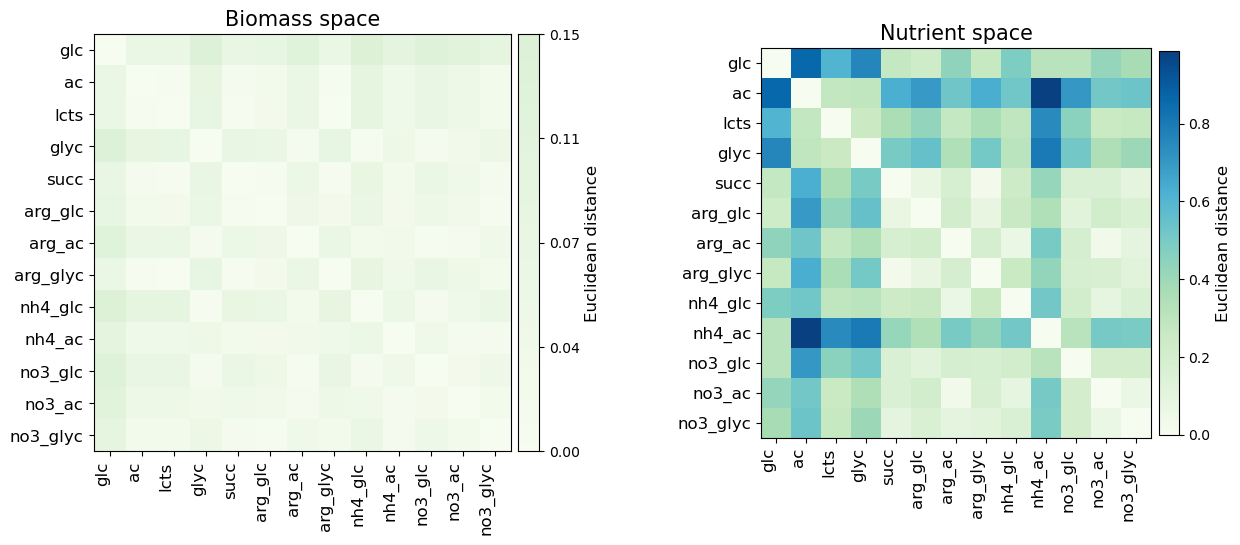

In [37]:
vmin = 0
vmax = max(DX_ordered.max(), DY_ordered.max())
vmax_biomass = DX_ordered.max()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, D, title in zip(axes, [DX_ordered, DY_ordered], ["Biomass space", "Nutrient space"]):
    im = ax.imshow(D, cmap="GnBu", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(env_order)))
    ax.set_yticks(range(len(env_order)))
    ax.set_xticklabels(env_order, rotation=90, ha="right", fontsize=12)
    ax.set_yticklabels(env_order, fontsize=12)
    ax.set_title(title, fontsize=15)

    if title == "Nutrient space":
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        cbar.set_label("Euclidean distance", fontsize=12)

fig.subplots_adjust(wspace=0.6)
fig.canvas.draw() 

biomass_pos = axes[0].get_position()
zoom_ax = fig.add_axes([
    biomass_pos.x1 + 0.005,
    biomass_pos.y0,
    0.015,
    biomass_pos.height
])

gradient = np.linspace(vmin, vmax, 256).reshape(256, 1)
zoom_ax.imshow(gradient[::-1], aspect="auto", cmap="GnBu", vmin=vmin, vmax=vmax)

frac = vmax_biomass / vmax
zoom_ax.set_ylim(255, 255 * (1 - frac))

zoom_ax.set_xticks([])
zoom_ax.yaxis.tick_right()
zoom_ax.yaxis.set_label_position("right")

n_ticks = 5
tick_vals = np.linspace(0, vmax_biomass, n_ticks)
tick_positions = np.linspace(255, 255 * (1 - frac), n_ticks)
zoom_ax.set_yticks(tick_positions)
zoom_ax.set_yticklabels([f"{v:.2f}" for v in tick_vals], fontsize=10)
zoom_ax.set_ylabel("Euclidean distance", fontsize=12)

plt.show()

## kNN

* X = biomass space
* Y = nutrient space

In [ ]:
k = 10
N = DX.shape[0]

knn_biomass = np.argsort(DX, axis=1)[:, 1:k+1]
knn_nutrient = np.argsort(DY, axis=1)[:, 1:k+1]
overlap_scores = []

for sample_idx in range(N):
    biomass_neighbors = set(knn_biomass[sample_idx])
    nutrient_neighbors = set(knn_nutrient[sample_idx])

    overlap = len(biomass_neighbors & nutrient_neighbors)
    overlap_scores.append(overlap / k)

overlap_scores = np.array(overlap_scores)
mean_preservation = overlap_scores.mean()
print(f"Mean neighborhood preservation, k={k}: {mean_preservation:.3f}")

Mean neighborhood preservation, k=10: 0.121


In [44]:
rng = np.random.default_rng(42)
random_scores = []

for i in range(N):
    possible = list(set(range(N)) - {i})
    random_neighbors = set(rng.choice(possible, size=k, replace=False))
    real_neighbors = set(knn_nutrient[i])
    
    overlap = len(random_neighbors & real_neighbors)
    random_scores.append(overlap / k)

print(f"Random baseline: {np.mean(random_scores):.4f}")
print(f"Analytical baseline: {k/N:.4f}")

Random baseline: 0.0070
Analytical baseline: 0.0069


**Trying different ks**

In [ ]:
ks = [5, 10, 20, 50]

for k in ks:

    knn_biomass = np.argsort(DX, axis=1)[:, 1:k+1]
    knn_nutrient = np.argsort(DY, axis=1)[:, 1:k+1]

    overlap_scores = []

    for i in range(DX.shape[0]):

        neigh_X = set(knn_biomass[i])
        neigh_Y = set(knn_nutrient[i])
        overlap = len(neigh_X & neigh_Y)
        overlap_scores.append(overlap / k)

    overlap_scores = np.array(overlap_scores)
    print(f"k={k}: preservation={overlap_scores.mean():.3f}")

k=5: preservation=0.119
k=10: preservation=0.121
k=20: preservation=0.123
k=50: preservation=0.126


## Rank correlation

In [ ]:
from scipy.stats import spearmanr
import numpy as np

rank_corrs = []
N = DX.shape[0]

for i in range(N):
    dx_i = DX[i]
    dy_i = DY[i]

    mask = np.arange(N) != i

    dx_i = dx_i[mask]
    dy_i = dy_i[mask]

    rho, _ = spearmanr(dx_i, dy_i)

    rank_corrs.append(rho)

rank_corrs = np.array(rank_corrs)

print(f"Mean Spearman rank correlation: {rank_corrs.mean():.3f}")
print(f"Median Spearman rank correlation: {np.median(rank_corrs):.3f}")

Mean Spearman rank correlation: 0.086
Median Spearman rank correlation: 0.087


In [ ]:
from scipy.stats import spearmanr
import numpy as np

i, j = np.triu_indices_from(DX, k=1)

dx = DX[i, j]
dy = DY[i, j]

rho, p = spearmanr(dx, dy)

print(f"Global Spearman rank correlation: {rho:.3f}")

Global Spearman rank correlation: 0.086


In [ ]:
from scipy.stats import spearmanr, rankdata


i, j = np.triu_indices_from(DX, k=1)

dx = DX[i, j]
dy = DY[i, j]

rank_dx = rankdata(dx)
rank_dy = rankdata(dy)

rho, p = spearmanr(rank_dx, rank_dy)

print(f"Spearman rank correlation: {rho:.4f}")
print(f"p-value: {p:.3e}")

Spearman rank correlation: 0.0858
p-value: 0.000e+00


In [36]:
rho, p = spearmanr(dx, dy)

print(rho)

0.08579109867892258
